In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Secilen ornek: 001ade2a3cb53fd808bd2856a0df5413.png


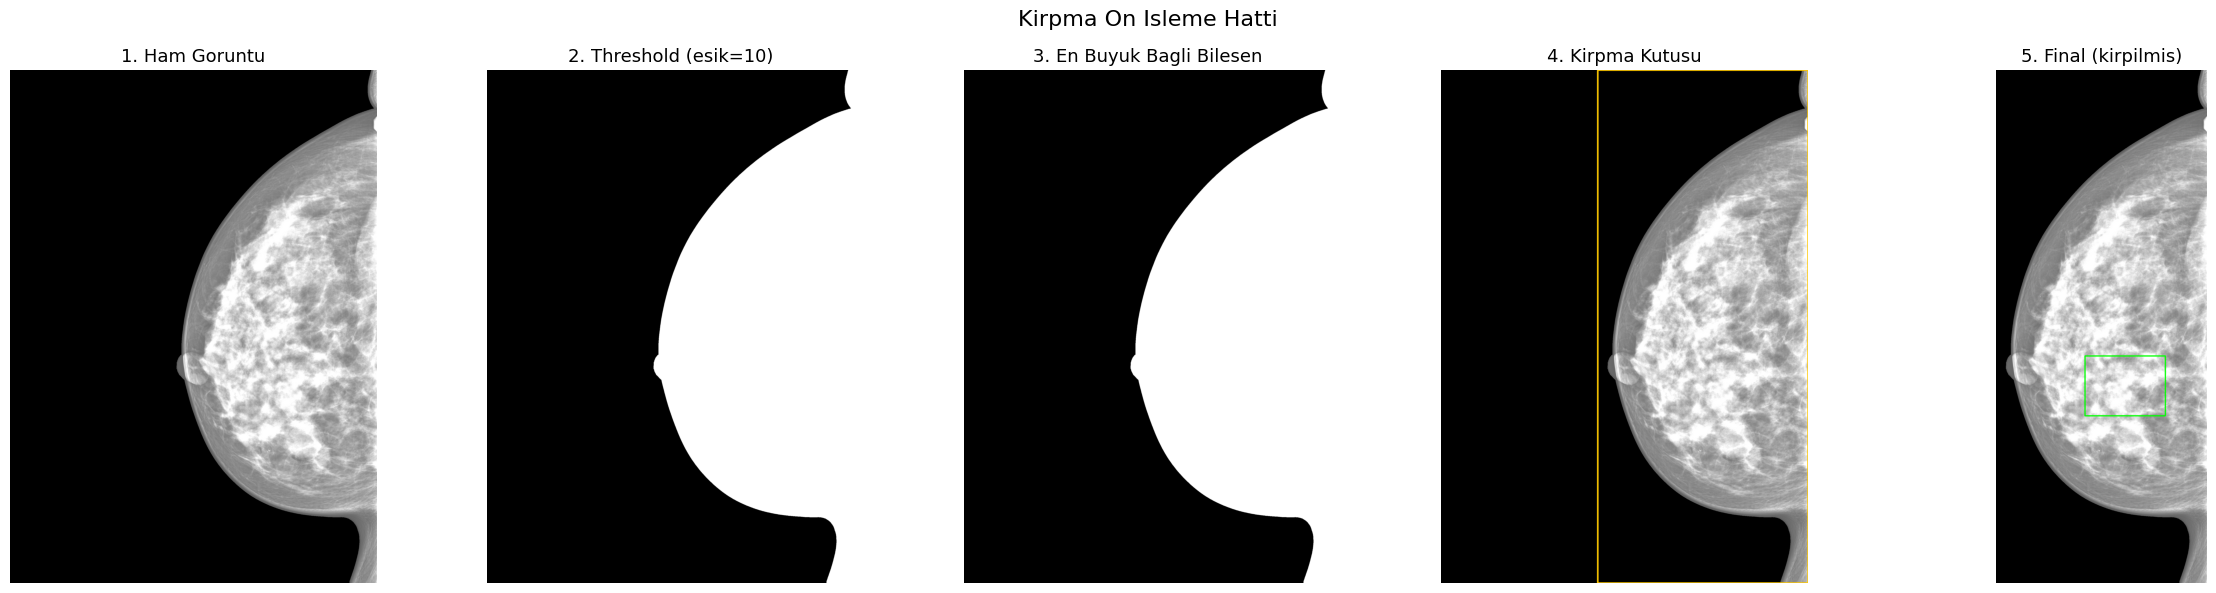

Kaydedildi: /content/drive/MyDrive/mass_detection/rapor_gorseller/onisleme_pipeline.png


In [2]:
# Colab'da (Drive mount edilmis) tek bir hucrede calistir.
# Rapor icin: Ham Goruntu -> Threshold -> Largest Component -> Crop -> Final
# tek bir 5 panelli sekil uretir, Drive'a kaydeder.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SRC_ROOT = '/content/drive/MyDrive/Kitle-Vindr&Tekno'
OUT_DIR = Path('/content/drive/MyDrive/mass_detection/rapor_gorseller')
OUT_DIR.mkdir(parents=True, exist_ok=True)

BG_THRESH = 10
MORPH_KERNEL = 9
PAD_RATIO = 0.05

TRAIN_IMG = Path(SRC_ROOT) / 'train' / 'images'
TRAIN_LBL = Path(SRC_ROOT) / 'train' / 'labels'


def load_gt(stem):
    lp = TRAIN_LBL / f'{stem}.txt'
    boxes = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                boxes.append([float(x) for x in parts[1:5]])
    return boxes


sample_path = None
for ip in sorted(TRAIN_IMG.glob('*.png')):
    if load_gt(ip.stem):
        sample_path = ip
        break
assert sample_path is not None, 'Etiketli ornek bulunamadi.'
print('Secilen ornek:', sample_path.name)

img_bgr = cv2.imread(str(sample_path))
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
h_img, w_img = gray.shape
gts = load_gt(sample_path.stem)

_, binary = cv2.threshold(gray, BG_THRESH, 255, cv2.THRESH_BINARY)

disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, disk)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
component = (labels == largest).astype(np.uint8) * 255

ys, xs = np.where(component > 0)
x1v, x2v = xs.min(), xs.max()
y1v, y2v = ys.min(), ys.max()
px = int((x2v - x1v) * PAD_RATIO)
py = int((y2v - y1v) * PAD_RATIO)
x1 = max(0, x1v - px); x2 = min(w_img, x2v + px)
y1 = max(0, y1v - py); y2 = min(h_img, y2v + py)

with_box = img_bgr.copy()
cv2.rectangle(with_box, (x1, y1), (x2, y2), (0, 200, 255), 8)

final = img_bgr[y1:y2, x1:x2].copy()
for (cx, cy, bw, bh) in gts:
    px1 = (cx - bw/2) * w_img - x1
    py1 = (cy - bh/2) * h_img - y1
    px2 = (cx + bw/2) * w_img - x1
    py2 = (cy + bh/2) * h_img - y1
    cv2.rectangle(final, (int(px1), int(py1)), (int(px2), int(py2)), (0, 255, 0), 6)


def show(ax, im, title, cmap=None):
    if im.ndim == 3:
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(im, cmap=cmap or 'gray')
    ax.set_title(title, fontsize=13)
    ax.axis('off')


fig, axes = plt.subplots(1, 5, figsize=(24, 6))
show(axes[0], img_bgr, '1. Ham Goruntu')
show(axes[1], binary, '2. Threshold (esik=10)')
show(axes[2], component, '3. En Buyuk Bagli Bilesen')
show(axes[3], with_box, '4. Kirpma Kutusu')
show(axes[4], final, '5. Final (kirpilmis)')
plt.suptitle('Kirpma On Isleme Hatti', fontsize=16)
plt.tight_layout()

out_path = OUT_DIR / 'onisleme_pipeline.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi:', out_path)
